Анализируем предварительно установленный датасет из Kaggle.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
data_path = PROJECT_ROOT / 'data' / 'cars.csv'
artifacts_path = PROJECT_ROOT / 'artifacts'

df = pd.read_csv(data_path)
print(df.shape)
print(df.info())
df.head()

(19237, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Manufacturer      19237 non-null  object 
 3   Model             19237 non-null  object 
 4   Prod. year        19237 non-null  int64  
 5   Category          19237 non-null  object 
 6   Leather interior  19237 non-null  object 
 7   Fuel type         19237 non-null  object 
 8   Engine volume     19237 non-null  object 
 9   Mileage           19237 non-null  object 
 10  Cylinders         19237 non-null  float64
 11  Gear box type     19237 non-null  object 
 12  Drive wheels      19237 non-null  object 
 13  Doors             19237 non-null  object 
 14  Wheel             19237 non-null  object 
 15  Color             19237 non-null  object 
 16  Airbags           19237 non-

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


### Параметры автомобиля по таблице:
`ID` - id автомобиля

`Price` - цена автомобиля

`Manufacturer` - его марка

`Prod. year` - год выпуска

`Category` - тип кузова

`Leather interior` - кожаный ли салог

`Fuel type` - тип используемого топлива

`Engine volume` - объём двигателя

`Mileage` - пробег

`Cylinders` - количество цилиндров в двигателе

`Gear box type` - тип коробки передач

`Drive wheels` - тип привода машины

`Door` - количество дверей

`Wheel` - расположение руля

`Color` - цвет автомобиля

`Airbags` - количество подушек безопасности

In [2]:
df.isnull().sum()

ID                  0
Price               0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

В датасете отсутствуют пропуски

Далее удалим все повторяющиеся строки

In [3]:
df=df.drop_duplicates()

Проверим есть ли повторяющиеся ID

In [4]:
df['ID'].duplicated().any()

np.False_

Я считаю, что `ID` машин больше не пригодится, поэтому его можно удалить

In [5]:
df=df.drop(['ID'],axis=1)

Далее приводим данные в нужный вид

In [6]:
# Цены изначально даны в долларах, переведу их в рубли по курсу
df['Price']=df['Price']*73

Затем все марки, котрые имеют меньше 15 примеров в таблице, меняем на 'other'. Это делается для того, чтобы при создании пайплайна у нас небыло нагроможения типов автомобилей для большей стабильности.

In [7]:
df['Manufacturer']=df['Manufacturer'].str.lower()
manufacturer_counts = df['Manufacturer'].value_counts()
rare_manufacturers = manufacturer_counts[manufacturer_counts < 15].index
df['Manufacturer'] = df['Manufacturer'].replace(rare_manufacturers, 'other')

In [8]:
# Аналогично маркам меняем и названия машин, но с порогом в 10
df['Model']=df['Model'].str.lower()
model_counts = df['Model'].value_counts()
rare_models = model_counts[model_counts < 10].index
df['Model'] = df['Model'].replace(rare_models, 'other')

In [9]:
df['Category'].unique() # проверяем есть ли опечатки или окибки

array(['Jeep', 'Hatchback', 'Sedan', 'Microbus', 'Goods wagon',
       'Universal', 'Coupe', 'Minivan', 'Cabriolet', 'Limousine',
       'Pickup'], dtype=object)

In [10]:
df['Fuel type'].unique() # проверяем есть ли опечатки или окибки

array(['Hybrid', 'Petrol', 'Diesel', 'CNG', 'Plug-in Hybrid', 'LPG',
       'Hydrogen'], dtype=object)

In [11]:
# Замена 'Plug-in Hybrid' на 'Hybrid'
df.loc[df['Fuel type'] == 'Plug-in Hybrid', 'Fuel type'] = 'hybrid'
# Замена 'CNG' и 'LPG' на 'Gas'
df.loc[(df['Fuel type'] == 'CNG') | (df['Fuel type'] == 'LPG'), 'Fuel type'] = 'gas'
df['Fuel type']=df['Fuel type'].str.lower()

In [12]:
df['Engine volume'].unique() # проверяем есть ли опечатки или окибки

array(['3.5', '3', '1.3', '2.5', '2', '1.8', '2.4', '4', '1.6', '3.3',
       '2.0 Turbo', '2.2 Turbo', '4.7', '1.5', '4.4', '3.0 Turbo',
       '1.4 Turbo', '3.6', '2.3', '1.5 Turbo', '1.6 Turbo', '2.2',
       '2.3 Turbo', '1.4', '5.5', '2.8 Turbo', '3.2', '3.8', '4.6', '1.2',
       '5', '1.7', '2.9', '0.5', '1.8 Turbo', '2.4 Turbo', '3.5 Turbo',
       '1.9', '2.7', '4.8', '5.3', '0.4', '2.8', '3.2 Turbo', '1.1',
       '2.1', '0.7', '5.4', '1.3 Turbo', '3.7', '1', '2.5 Turbo', '2.6',
       '1.9 Turbo', '4.4 Turbo', '4.7 Turbo', '0.8', '0.2 Turbo', '5.7',
       '4.8 Turbo', '4.6 Turbo', '6.7', '6.2', '1.2 Turbo', '3.4',
       '1.7 Turbo', '6.3 Turbo', '2.7 Turbo', '4.3', '4.2', '2.9 Turbo',
       '0', '4.0 Turbo', '20', '3.6 Turbo', '0.3', '3.7 Turbo', '5.9',
       '5.5 Turbo', '0.2', '2.1 Turbo', '5.6', '6', '0.7 Turbo',
       '0.6 Turbo', '6.8', '4.5', '0.6', '7.3', '0.1', '1.0 Turbo', '6.3',
       '4.5 Turbo', '0.8 Turbo', '4.2 Turbo', '3.1', '5.0 Turbo', '6.4',
       '3

In [13]:
df['Engine volume']=df['Engine volume'].str.replace(" Turbo","")
df['Engine volume']=df['Engine volume'].astype(float)

In [14]:
df['Leather interior'].unique() # проверяем есть ли опечатки или окибки

array(['Yes', 'No'], dtype=object)

In [15]:
df['Mileage'] = df['Mileage'].str.replace(' km', '').astype(int)

In [16]:
df['Gear box type'].unique()

array(['Automatic', 'Tiptronic', 'Variator', 'Manual'], dtype=object)

In [17]:
df['Drive wheels'].unique()

array(['4x4', 'Front', 'Rear'], dtype=object)

In [18]:
df['Drive wheels']=df['Drive wheels'].str.lower()

In [19]:
df['Doors'].unique() # проверяем есть ли опечатки или окибки

array(['04-May', '02-Mar', '>5'], dtype=object)

In [20]:
# Заменим на более простые для понимания
df.loc[df['Doors'] == '04-May', 'Doors'] = '4'
df.loc[df['Doors'] == '02-Mar', 'Doors'] = '2'

In [21]:
df['Wheel'].unique() # проверяем есть ли опечатки или окибки

array(['Left wheel', 'Right-hand drive'], dtype=object)

In [22]:
# Заменим на более простые для понимания
df.loc[df['Wheel'] == 'Left wheel', 'Wheel'] = 'left'
df.loc[df['Wheel'] == 'Right-hand drive', 'Wheel'] = 'right'

In [23]:
df['Color'].unique()

array(['Silver', 'Black', 'White', 'Grey', 'Blue', 'Green', 'Red',
       'Sky blue', 'Orange', 'Yellow', 'Brown', 'Golden', 'Beige',
       'Carnelian red', 'Purple', 'Pink'], dtype=object)

In [24]:
df['Color']=df['Color'].str.lower()

Далее фильтруем значения чтобы избежать больших выбросов(проверять на выбросы трудно, т.к. у разных машин могут быть разные параметры, которые могут показаться аномальными, поэтому я просто обрезаю небольшой диапазон самых больших значений)

In [25]:
df = df[(df['Price'] > 50000) & (df['Price'] < df['Price'].quantile(0.98))]
df = df[(df['Prod. year'] >= 1970) & (df['Prod. year'] <= 2026)]
df = df[df['Mileage'] >= 0]
df = df[df['Engine volume'] > 0 & (df['Engine volume'] < df['Engine volume'].quantile(0.98))]
df = df[(df['Cylinders'] > 0) & (df['Cylinders'] < 16)]

Далее посмотрим некоторые данный на графиках

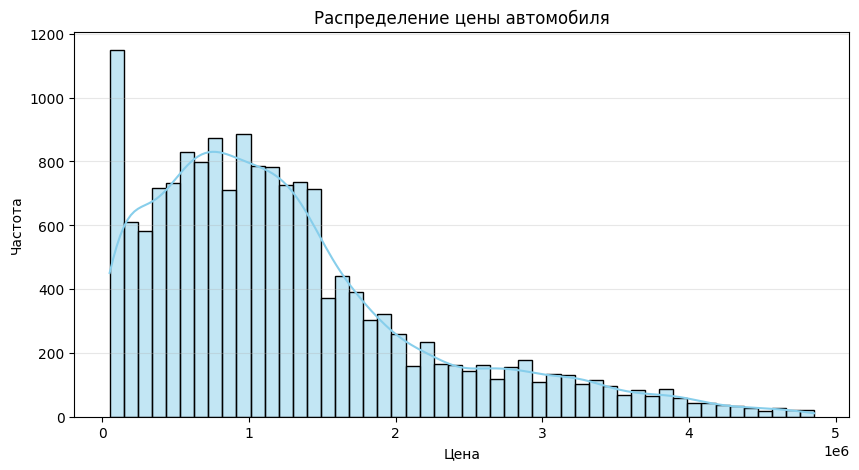

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=50, kde=True, color='skyblue')
plt.title('Распределение цены автомобиля')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)
plt.savefig(artifacts_path / 'price_distribution.png')
plt.show()

Виден скос распределения, что логично, ведь большенство машин имеет небольшую цену. Это означает, что если использовать для моделей основную метрику RMSE, то она может показывать большую ошибку из-за дорогих машин. Поэтому также будем использовать мае MAE для большей интерпретируемости резкльтата. Также бдет не лишним использовать в качестве таргета логарифмированную цену.

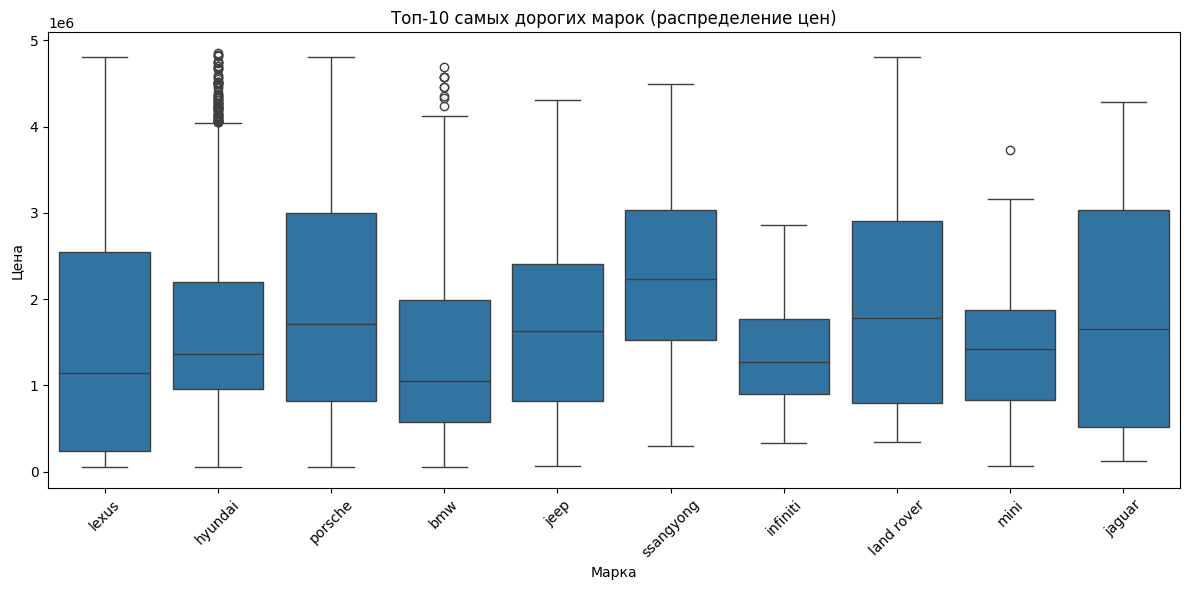

In [27]:
# Вычисляем топ-10 марок по средней цене
top_brands = df.groupby('Manufacturer')['Price'].mean().nlargest(10).index

# Создаём отдельную фигуру
plt.figure(figsize=(12, 6))
sns.boxplot(x='Manufacturer', y='Price', data=df[df['Manufacturer'].isin(top_brands)])
plt.xticks(rotation=45)
plt.title('Топ-10 самых дорогих марок (распределение цен)')
plt.xlabel('Марка')
plt.ylabel('Цена')
plt.tight_layout()
plt.savefig(artifacts_path / 'top10_marks_distribution.png')
plt.show()

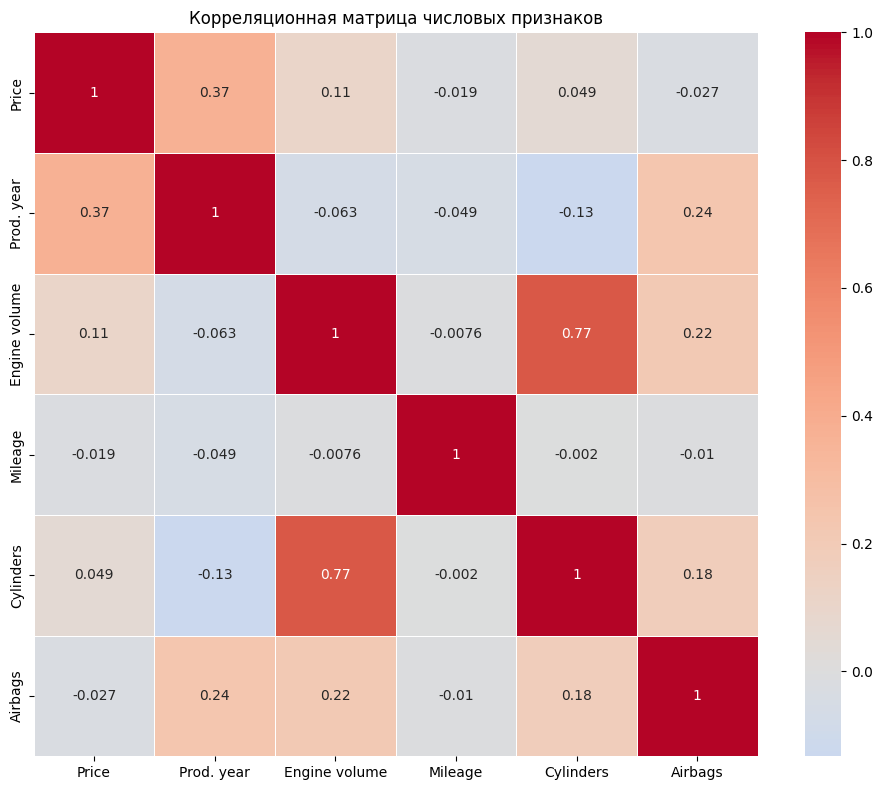

In [28]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.savefig(artifacts_path / 'heat_map.png')
plt.show()

Цена слабо линейно связана с числовыми признаками - максимум 0.37 у года выпуска, остальные <0.2.

Сильная мультиколлинеарность между объёмом двигателя и количеством цилиндров (0.77) - для линейных моделей можно будет оставить что-то одно.

Пробег почти не коррелирует ни с ценой, ни с годом (коэф. около 0) - нужно проверить на аномалии.

Подушки безопасности и кожаный салон почти не влияют на цену (корреляции близки к нулю) - можно будет проверить точность модели без них.

In [29]:
df['Mileage'].describe()

count    1.652100e+04
mean     1.431841e+06
std      4.577924e+07
min      0.000000e+00
25%      7.147900e+04
50%      1.259260e+05
75%      1.853670e+05
max      2.147484e+09
Name: Mileage, dtype: float64

In [30]:
# Есть аномально большие значения, поэтому удалим машины с пробегом больше 10^6
df=df[df['Mileage']<1000000]

Проверем, что теперь влияние пробега не нулевое

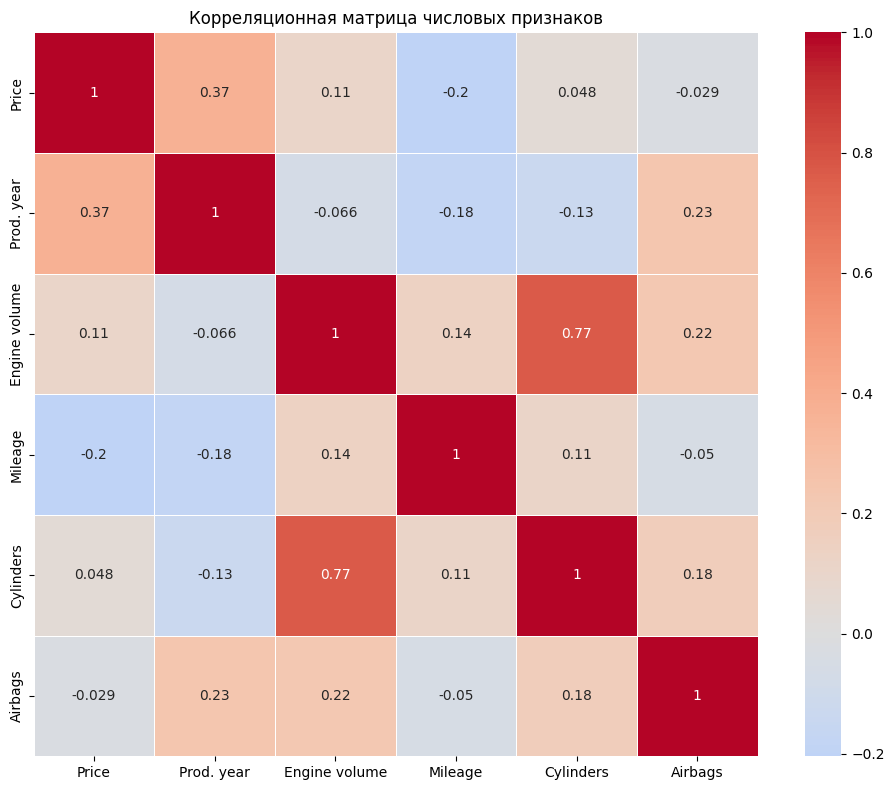

In [31]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.savefig(artifacts_path / 'heat_map_update.png')
plt.show()

Теперь напишу функцию обработки сырых данных, чтобы потом можно бужет удобно использовать из этого файла.

In [32]:
def prepare_raw_data(df):
    df=df.drop_duplicates()
    
    df=df.drop(['ID'],axis=1)
    
    df['Price']=df['Price']*73
    
    df['Manufacturer']=df['Manufacturer'].str.lower()
    
    manufacturer_counts = df['Manufacturer'].value_counts()
    rare_manufacturers = manufacturer_counts[manufacturer_counts < 15].index
    df['Manufacturer'] = df['Manufacturer'].replace(rare_manufacturers, 'other')

    df['Model']=df['Model'].str.lower()
    model_counts = df['Model'].value_counts()
    rare_models = model_counts[model_counts < 10].index
    df['Model'] = df['Model'].replace(rare_models, 'other')
    
    df.loc[df['Fuel type'] == 'Plug-in Hybrid', 'Fuel type'] = 'hybrid'
    df.loc[(df['Fuel type'] == 'CNG') | (df['Fuel type'] == 'LPG'), 'Fuel type'] = 'gas'
    df['Fuel type']=df['Fuel type'].str.lower()

    df['Engine volume']=df['Engine volume'].str.replace(" Turbo","")
    df['Engine volume']=df['Engine volume'].astype(float)

    df['Mileage'] = df['Mileage'].str.replace(' km', '').astype(int)

    df['Drive wheels']=df['Drive wheels'].str.lower()

    df.loc[df['Doors'] == '04-May', 'Doors'] = '4'
    df.loc[df['Doors'] == '02-Mar', 'Doors'] = '2'

    df.loc[df['Wheel'] == 'Left wheel', 'Wheel'] = 'left'
    df.loc[df['Wheel'] == 'Right-hand drive', 'Wheel'] = 'right'

    df['Color']=df['Color'].str.lower()

    df = df[(df['Price'] > 50000) & (df['Price'] < df['Price'].quantile(0.98))]
    df = df[(df['Prod. year'] >= 1970) & (df['Prod. year'] <= 2026)]
    df = df[df['Mileage'] >= 0]
    df = df[df['Engine volume'] > 0 & (df['Engine volume'] < df['Engine volume'].quantile(0.98))]
    df = df[(df['Cylinders'] > 0) & (df['Cylinders'] < 16)]

    df=df[df['Mileage']<1000000]

    return df